In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# 加載數據集
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 轉換為 Pandas DataFrame 方便查看
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map(lambda x: target_names[x])
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  


2.2 數據可視化
使用 Matplotlib 和 Seaborn 繪製特徵之間的關係圖和分佈圖。

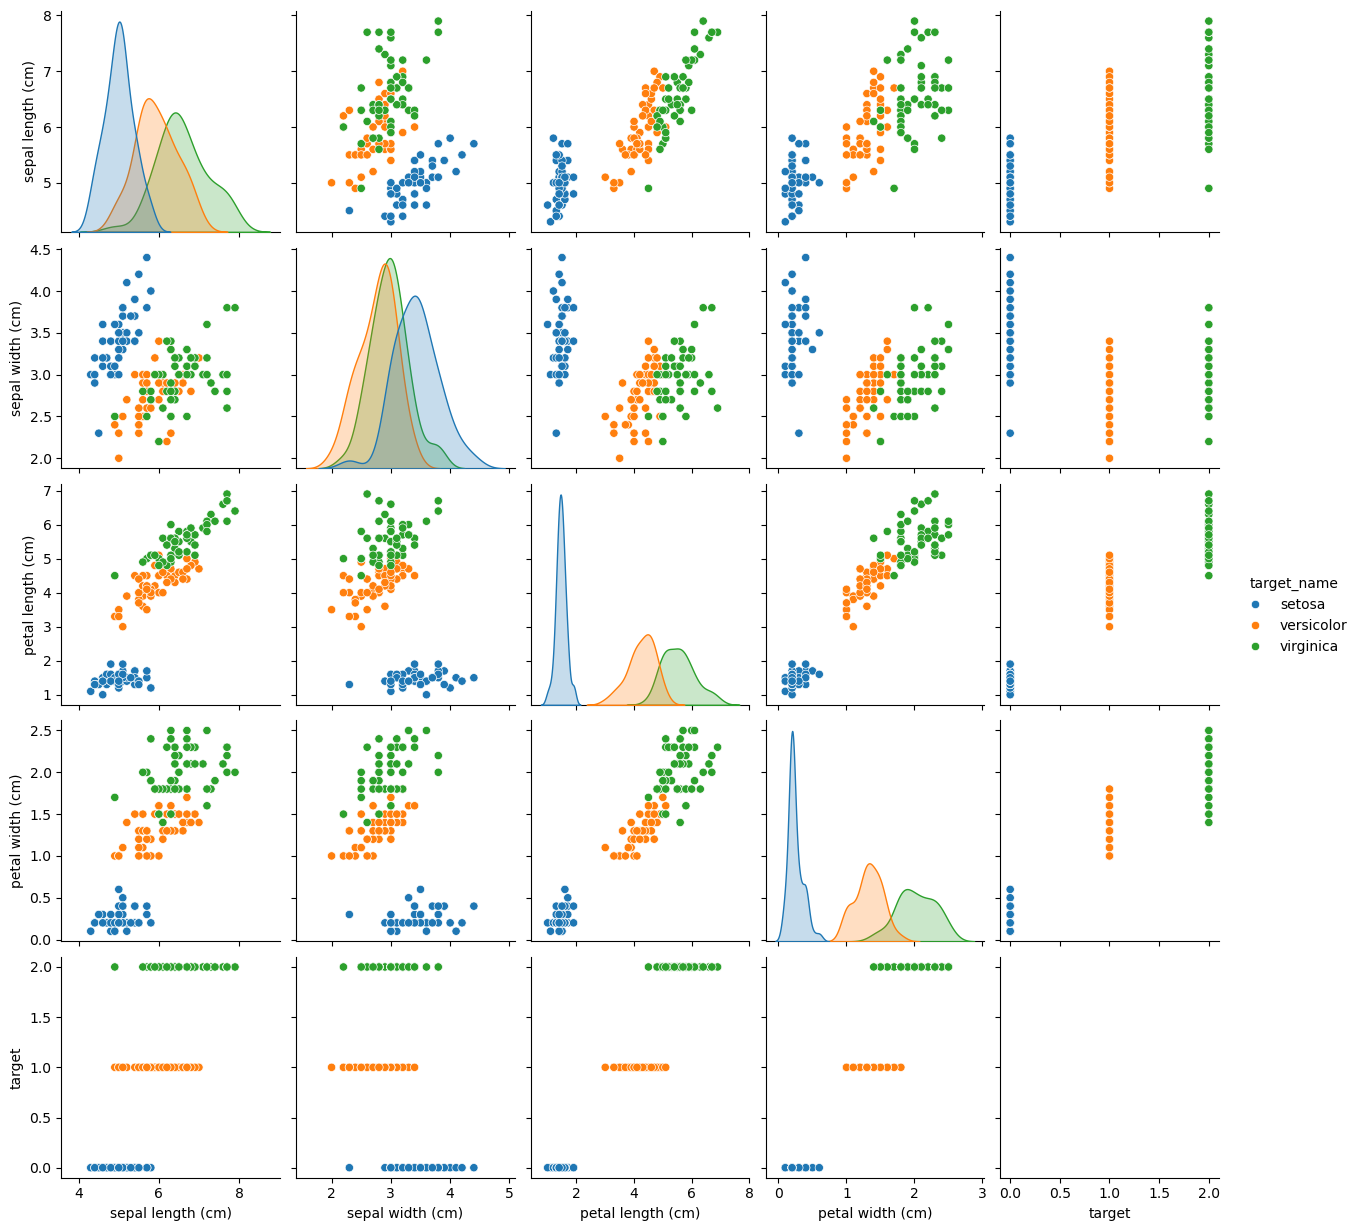

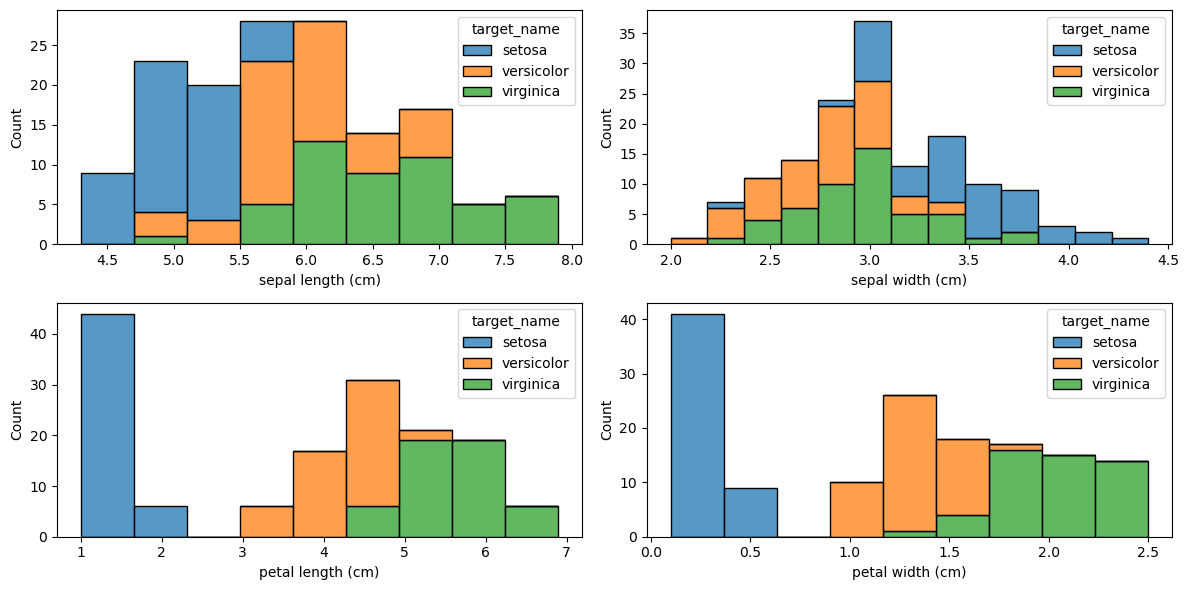

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 特徵之間的關係圖
sns.pairplot(df, hue='target_name')
plt.show()

# 特徵分佈圖
plt.figure(figsize=(12, 6))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df, x=feature, hue='target_name', multiple='stack')
plt.tight_layout()
plt.show()

2.3 特徵工程
對數據進行標準化處理，以便更好地應用模型。

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 划分訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 標準化處理
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2.4 模型訓練與評估
2.4.1 隨機森林

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 訓練模型
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# 預測與評估
y_pred_rf = rf.predict(X_test_scaled)
print("隨機森林混淆矩陣：")
print(confusion_matrix(y_test, y_pred_rf))
print("隨機森林分類報告：")
print(classification_report(y_test, y_pred_rf))

隨機森林混淆矩陣：
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
隨機森林分類報告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



2.4.2 貝葉斯分類

In [5]:
from sklearn.naive_bayes import GaussianNB

# 訓練模型
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# 預測與評估
y_pred_nb = nb.predict(X_test_scaled)
print("貝葉斯分類混淆矩陣：")
print(confusion_matrix(y_test, y_pred_nb))
print("貝葉斯分類分類報告：")
print(classification_report(y_test, y_pred_nb))

貝葉斯分類混淆矩陣：
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
貝葉斯分類分類報告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



2.4.3 SVM

In [6]:
from sklearn.svm import SVC

# 訓練模型
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

# 預測與評估
y_pred_svm = svm.predict(X_test_scaled)
print("SVM 混淆矩陣：")
print(confusion_matrix(y_test, y_pred_svm))
print("SVM 分類報告：")
print(classification_report(y_test, y_pred_svm))

SVM 混淆矩陣：
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
SVM 分類報告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



2.4.4 集成學習（Adaboost）

In [7]:
from sklearn.ensemble import AdaBoostClassifier

# 訓練模型
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_scaled, y_train)

# 預測與評估
y_pred_ada = ada.predict(X_test_scaled)
print("Adaboost 混淆矩陣：")
print(confusion_matrix(y_test, y_pred_ada))
print("Adaboost 分類報告：")
print(classification_report(y_test, y_pred_ada))

Adaboost 混淆矩陣：
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Adaboost 分類報告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



2.5 超參數調優（GridSearchCV）
以隨機森林為例，進行超參數調優。

In [8]:
from sklearn.model_selection import GridSearchCV

# 定義參數網格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# 使用 GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# 查看最佳參數和結果
print("最佳參數：", grid_search.best_params_)
print("最佳分數：", grid_search.best_score_)

最佳參數： {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
最佳分數： 0.9428571428571428


2.6 學習曲線
繪製隨機森林的學習曲線。

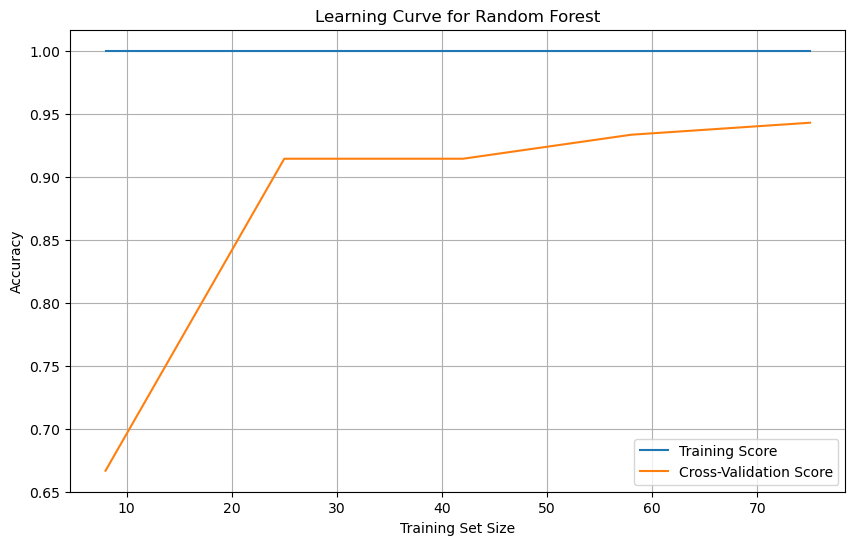

In [9]:
from sklearn.model_selection import learning_curve

# 獲取學習曲線數據
train_sizes, train_scores, test_scores = learning_curve(estimator=RandomForestClassifier(random_state=42), X=X_train_scaled, y=y_train, cv=5, n_jobs=-1, train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9])

# 繪製學習曲線
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve for Random Forest')
plt.legend()
plt.grid()
plt.show()

2.7 總結比較表格
將各模型的評估指標進行比較。

In [10]:
import numpy as np

# 總結表格
results = {
    'Model': ['Random Forest', 'Naive Bayes', 'SVM', 'Adaboost'],
    'Accuracy': [np.mean(y_test == y_pred_rf), np.mean(y_test == y_pred_nb), np.mean(y_test == y_pred_svm), np.mean(y_test == y_pred_ada)],
    'Precision': [classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['precision'],
                  classification_report(y_test, y_pred_nb, output_dict=True)['weighted avg']['precision'],
                  classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['precision'],
                  classification_report(y_test, y_pred_ada, output_dict=True)['weighted avg']['precision']],
    'Recall': [classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['recall'],
               classification_report(y_test, y_pred_nb, output_dict=True)['weighted avg']['recall'],
               classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['recall'],
               classification_report(y_test, y_pred_ada, output_dict=True)['weighted avg']['recall']],
    'F1-Score': [classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['f1-score'],
                 classification_report(y_test, y_pred_nb, output_dict=True)['weighted avg']['f1-score'],
                 classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['f1-score'],
                 classification_report(y_test, y_pred_ada, output_dict=True)['weighted avg']['f1-score']]
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  1.000000   1.000000  1.000000  1.000000
1    Naive Bayes  0.977778   0.979365  0.977778  0.977745
2            SVM  1.000000   1.000000  1.000000  1.000000
3       Adaboost  1.000000   1.000000  1.000000  1.000000
